In [147]:
import pandas as pd
import numpy as np

# Load the dataset
original_df = pd.read_csv('C:\\Users\\esomw\\OneDrive\\Documents\\DataScience_Workspace\\Fraud_Detection_Project\\data\\nova_pay_combined.csv')

# Create a copy of the dataset
df = original_df.copy()

# Display basic dataset information
print("Original dataset shape:", original_df.shape)
print("Working copy shape:", df.shape)

# Display the first few rows of the dataset
df.head()

Original dataset shape: (11400, 26)
Working copy shape: (11400, 26)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

In [149]:
# 1. Drop irrelevant columns (Identfiers)

# Identifiers columns do not usually contribute to the predictive power of the model and can be safely removed.
identifier_columns = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address"
]

# Drop the identifier columns
df.drop(columns=identifier_columns, inplace=True)

print("Dataset shape after dropping identifier columns:", df.shape)
df.head()





Dataset shape after dropping identifier columns: (11400, 22)


,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,True,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,False,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,False,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,False,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [150]:
# 2.  Check and deal with duplicates

# check numbers of duplicates
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Reset index after removing duplicates
df.reset_index(drop=True, inplace=True)

print("Dataset shape after removing duplicates:", df.shape)



Number of duplicate rows: 200
Dataset shape after removing duplicates: (11200, 22)


In [151]:
# 4. Fix Inconsistencies in Categorical Variables

# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

# Standardize text formatting in categorical columns
for col in categorical_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

# Display unique values in categorical columns to check for inconsistencies
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in timestamp:
<StringArray>
['2022-10-03_18:40:59.468549+00:00', '2022-10-03_20:39:38.468549+00:00',
 '2022-10-03_23:02:43.468549+00:00', '2022-10-04_01:08:53.468549+00:00',
 '2022-10-04_09:35:03.468549+00:00', '2022-10-04_12:09:59.468549+00:00',
 '2022-10-04_12:37:41.468549+00:00', '2022-10-04_16:27:44.468549+00:00',
 '2022-10-04_21:00:36.468549+00:00', '2022-10-04_21:20:42.468549+00:00',
 ...
 '2025-11-24_13:42:17.573611+00:00', '2025-11-25_00:45:10.573611+00:00',
 '2025-11-25_07:44:29.573611+00:00', '2025-11-25_07:56:54.573611+00:00',
 '2025-11-25_09:48:28.573611+00:00', '2025-11-25_10:05:35.573611+00:00',
 '2025-11-26_07:09:56.573611+00:00', '2025-11-27_06:19:11.573611+00:00',
 '2025-11-28_00:53:28.573611+00:00', '2025-11-29_20:10:47.573611+00:00']
Length: 11142, dtype: str

Unique values in home_country:
<StringArray>
['us', 'ca', 'uk', 'unknown']
Length: 4, dtype: str

Unique values in source_currency:
<StringArray>
['usd', 'cad', 'gbp']
Length: 3, dtype: str

Uniq

C:\Users\esomw\AppData\Local\Temp\ipykernel_14980\650083192.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [152]:
# Correct spelling inconsistencies in kyc_tier

df["kyc_tier"] = df["kyc_tier"].replace({
    "standrd": "standard",
    "enhancd": "enhanced",
    "nan": "unknown"
})

# Verify cleaned values
print("Unique values in kyc_tier after correction:")
print(df["kyc_tier"].unique())


df["channel"] = df["channel"].replace({
    "mobille": "mobile",
    "weeb": "web",
})

# Verify cleaned values
print("Unique values in channel after correction:")
print(df["channel"].unique())

Unique values in kyc_tier after correction:
<StringArray>
['standard', 'enhanced', 'low', nan, 'unknown']
Length: 5, dtype: str
Unique values in channel after correction:
<StringArray>
['atm', 'web', 'mobile', 'unknown']
Length: 4, dtype: str


In [153]:
# ==============================
# Final Check
# ==============================

# Display cleaned dataset information
print("Cleaned dataset shape:", df.shape)
print("\nDataset information:")
df.info()

# Preview cleaned dataset
df.head(20)

Cleaned dataset shape: (11200, 22)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp                  11171 non-null  str    
 1   home_country               11200 non-null  str    
 2   source_currency            11200 non-null  str    
 3   dest_currency              11200 non-null  str    
 4   channel                    11200 non-null  str    
 5   amount_src                 11200 non-null  str    
 6   amount_usd                 10900 non-null  float64
 7   fee                        10910 non-null  float64
 8   exchange_rate_src_to_dest  11200 non-null  float64
 9   new_device                 11200 non-null  bool   
 10  ip_country                 10904 non-null  str    
 11  location_mismatch          11200 non-null  bool   
 12  ip_risk_score              11200 non-null  float64
 13  

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,2022-10-03_18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,False,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.00,0
1,2022-10-03_20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,True,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.00,0
2,2022-10-03_23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,False,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.00,0
3,2022-10-04_01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,False,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.00,0
4,2022-10-04_09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,False,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.00,0
5,2022-10-04_12:09:59.468549+00:00,us,usd,gbp,mobile,526.9,526.90,8.75,0.800000,False,us,False,0.094,low,616,0.702,0,0.361,0,0,0.00,0
6,2022-10-04_12:37:41.468549+00:00,ca,cad,gbp,mobile,149.24,110.44,2.33,0.592000,False,ca,False,0.299,standard,947,0.625,0,0.268,0,0,0.00,0
7,2022-10-04_16:27:44.468549+00:00,ca,cad,inr,web,276.51,204.62,5.59,61.666667,False,ca,False,0.087,standard,1041,0.867,0,0.245,0,1,0.12,0
8,2022-10-04_21:00:36.468549+00:00,us,usd,eur,mobile,99.52,99.52,2.41,0.925926,False,us,False,0.182,enhanced,367,0.939,0,0.176,0,0,0.00,0
9,2022-10-04_21:20:42.468549+00:00,us,usd,php,web,302.55,302.55,5.26,58.823529,False,us,False,0.413,standard,1016,0.944,0,0.247,0,0,0.10,1


# 3. Deal with Null Values

In [154]:
# 3. Deal with Null Values

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
new_device                     0
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64


In [155]:
#pd.set_option("display.max_rows", None)
#display(df[df["amount_usd"].isna()])

# Handling missing values in amount_usd
- Step 1 — Create Currency-to-USD Conversion Mapping

- Step 2 — Compute Average Conversion Rate Per Currency

- Step 3 — Fill Missing amount_usd using source amount * conversion rate


In [156]:
# Create conversion ratio
# remove currency symbols/commas and coerce
df["amount_usd"] = pd.to_numeric(
    df["amount_usd"].astype(str).str.replace(r"[^0-9\.-]", "", regex=True),
    errors="coerce"
)
df["amount_src"] = pd.to_numeric(
    df["amount_src"].astype(str).str.replace(r"[^0-9\.-]", "", regex=True),
    errors="coerce"
)

# avoid divide-by-zero/NaN
df["usd_conversion_rate"] = df["amount_usd"] / df["amount_src"].replace({0: np.nan})

In [157]:
# Average USD conversion rate by source currency
conversion_map = df.groupby("source_currency")[
    "usd_conversion_rate"
].median()

print(conversion_map)

source_currency
cad    0.74
gbp    1.25
usd    1.00
Name: usd_conversion_rate, dtype: float64


In [158]:
# Function to reconstruct amount_usd
def fill_amount_usd(row):

    # If amount_usd already exists, keep it
    if pd.notnull(row["amount_usd"]):
        return row["amount_usd"]

    currency = row["source_currency"]

    # Use learned conversion rate
    if currency in conversion_map:
        return row["amount_src"] * conversion_map[currency]

    return np.nan

# Apply reconstruction
df["amount_usd"] = df.apply(fill_amount_usd, axis=1)

In [159]:
# Check missing values
print("Missing values after filling amount_usd:")
print(df.isnull().sum())

Missing values after filling amount_usd:
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          290
exchange_rate_src_to_dest      0
new_device                     0
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
usd_conversion_rate          300
dtype: int64


# Dealing with missing values in "fee" column
  Fee is dependent on the transaction amount and the channel used
- Create Fee Percentage
- Determine Median Fee Rate by Channel (median because of the presence of outliers)
- Fill missing Fee using the channel fee rate

In [160]:
# Calculate fee rate
df["fee_rate"] = df["fee"] / df["amount_usd"].replace({0: np.nan})

In [161]:
# Median fee rate per channel

channel_fee_rate = df.groupby("channel")["fee_rate"].median()

print(channel_fee_rate)

channel
atm        0.020445
mobile     0.020854
unknown    0.021754
web        0.020570
Name: fee_rate, dtype: float64


In [162]:
# Fill missing fee using amount_usd and channel fee rate

def fill_fee(row):

    # Keep existing fee
    if pd.notnull(row["fee"]):
        return row["fee"]

    channel = row["channel"]

    # Recalculate fee
    if channel in channel_fee_rate:
        return row["amount_usd"] * channel_fee_rate[channel]

    return np.nan

# Apply reconstruction
df["fee"] = df.apply(fill_fee, axis=1)

In [163]:
# Check missing values
print("Missing values after filling fee:")
print(df.isnull().sum())

Missing values after filling fee:
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
new_device                     0
ip_country                   296
location_mismatch              0
ip_risk_score                  0
kyc_tier                     295
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
usd_conversion_rate          300
fee_rate                     290
dtype: int64


# Dealing with timestamp missing values
Since the number of missing values is only 29 out of over 11,000 rows, the best option is to drop the rows.

In [164]:
# Check missing timestamps
print(df["timestamp"].isnull().sum())

# Remove rows with missing timestamps
df = df.dropna(subset=["timestamp"])

# Confirm removal
print(df["timestamp"].isnull().sum())

29
0


# Dealing with IP_Country missing values
Since home_country is present in the dataset, best option is to replace missing IP country with Home country.

In [165]:
# Check missing values
print(df["ip_country"].isnull().sum())

# Fill missing ip_country using home_country
df["ip_country"] = df["ip_country"].fillna(
    df["home_country"]
)

# Confirm changes
print(df["ip_country"].isnull().sum())

296
0


# Dealing with kyc_tier missing values
The best option is to replace missing kyc with "unknown" because missing KYC information may itself indicate:
- incomplete onboarding,
- weak verification,
- suspicious users,
- higher fraud risk.

In [166]:
# Check missing values
print(df["kyc_tier"].isnull().sum())

# Replace missing KYC values with 'unknown'
df["kyc_tier"] = df["kyc_tier"].fillna(
    "unknown"
)

# Confirm changes
print(df["kyc_tier"].isnull().sum())

295
0


# Dealing with Device_trust_score
Use grouped median imputation based on:
- new_device
- location_mismatch

In [167]:
# Analyze device trust behavior

df.groupby(
    ["new_device", "location_mismatch"]
)["device_trust_score"].describe()

count      mean       std  min      25%    50%  \
new_device location_mismatch                                                    
False      False              8269.0  0.695781  0.250792 -0.1  0.52200  0.814   
           True               1306.0  0.628091  0.283694 -0.1  0.36875  0.607   
True       False               822.0  0.499125  0.260090 -0.1  0.31350  0.401   
           True                484.0  0.253329  0.198748 -0.1  0.13000  0.194   

                                75%    max  
new_device location_mismatch                
False      False              0.934  0.999  
           True               0.894  0.960  
True       False              0.744  0.980  
           True               0.324  0.937

In [168]:
# Create grouped median trust scores

device_trust_map = df.groupby(
    ["new_device", "location_mismatch"]
)["device_trust_score"].median()

print(device_trust_map)

new_device  location_mismatch
False       False                0.814
            True                 0.607
True        False                0.401
            True                 0.194
Name: device_trust_score, dtype: float64


In [169]:

# Function to fill missing device trust score

def fill_device_trust(row):

    # Keep existing values
    if pd.notnull(row["device_trust_score"]):
        return row["device_trust_score"]

    key = (
        row["new_device"],
        row["location_mismatch"]
    )

    # Use grouped median
    if key in device_trust_map:
        return device_trust_map[key]

    return np.nan

# Apply reconstruction
df["device_trust_score"] = df.apply(
    fill_device_trust,
    axis=1
)

# Confirm missing values resolved

print(df["device_trust_score"].isnull().sum())

0


# Dropping Temporary columns 
- Fee_rate
- usd_conversion_rate

In [170]:
# Remove temporary helper columns

df.drop(
    columns=["usd_conversion_rate", "fee_rate"],
    inplace=True
)

print("Temporary columns removed.")

print("Missing values after cleaning:")
print(df.isnull().sum())

Temporary columns removed.
Missing values after cleaning:
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64


# Exploratory Data Analysis
This will help to understand:

- fraud patterns,
- transaction behavior,
- variable distributions,
- correlations,
- anomalies,
- and relationships between features and the target variable (is_fraud).

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")

# Statistical Summary
df.describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000,11171.000000
mean,437.344437,448.602460,97.059447,167.693687,0.397841,393.086205,0.655705,0.049503,0.267719,0.464417,0.733327,0.045440,0.088980
std,1371.808537,1392.495721,941.441853,382.183198,0.271418,342.231395,0.271001,0.258711,0.143587,1.533937,1.972746,0.084913,0.284728
min,-9997.160000,-373.890000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,90.750000,92.450000,2.370000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,159.020000,163.420000,3.500000,7.142857,0.325000,298.000000,0.702000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,295.365000,302.725000,5.575000,73.529412,0.489000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,11942.890000,12498.575000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000



# 1. Check Fraud Distribution

    This is VERY important because fraud datasets are usually imbalanced

In [172]:
# Fraud class distribution
print(df["is_fraud"].value_counts())

# Percentage distribution
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    10177
1      994
Name: count, dtype: int64
is_fraud
0    91.10196
1     8.89804
Name: proportion, dtype: float64


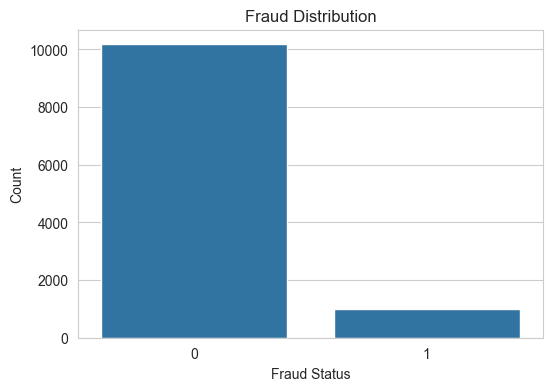

In [173]:
# Fraud Distribution Visualization
plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=df)

plt.title("Fraud Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Count")

plt.show()

## Numerical Feature Distribution

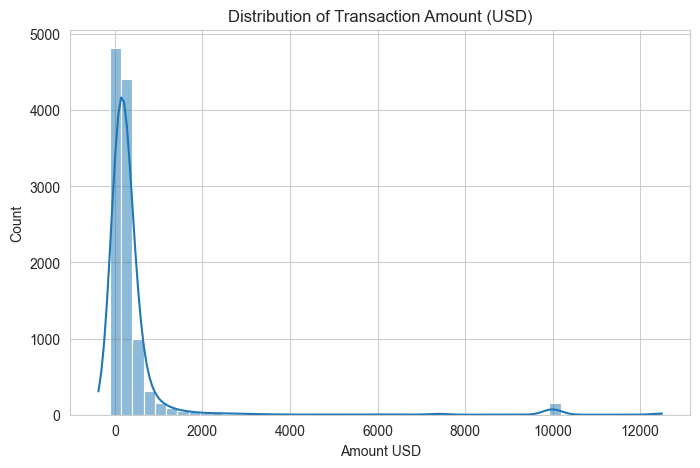

In [174]:
# Distribution of Transaction Amount

plt.figure(figsize=(8,5))

sns.histplot(df["amount_usd"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount (USD)")
plt.xlabel("Amount USD")

plt.show()

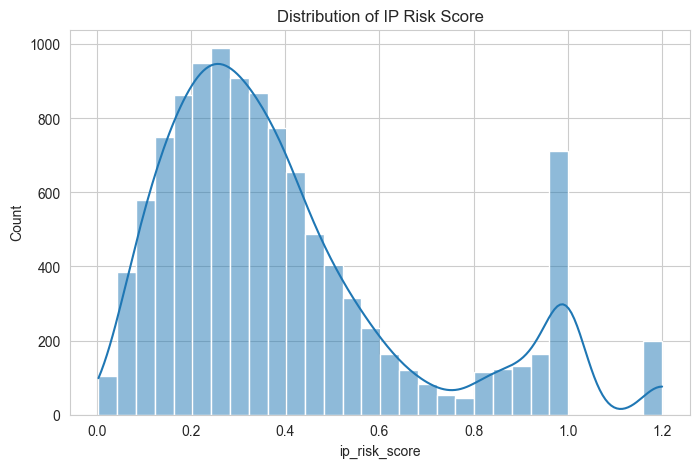

In [175]:
# Distribution of IP Risk Score

plt.figure(figsize=(8,5))

sns.histplot(df["ip_risk_score"], bins=30, kde=True)

plt.title("Distribution of IP Risk Score")

plt.show()

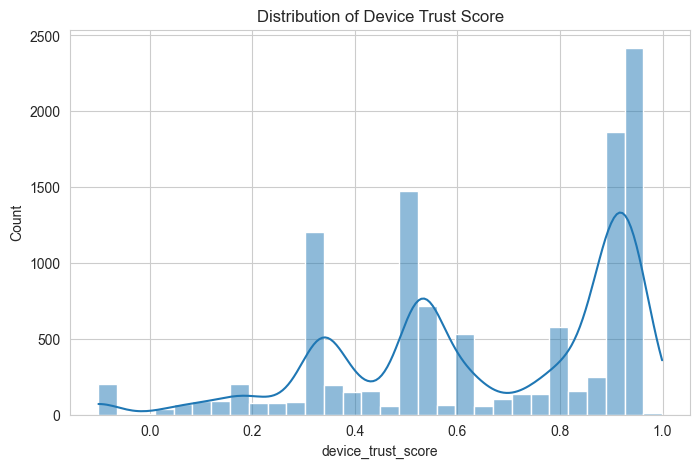

In [176]:
# Distribution of Device Trust Score

plt.figure(figsize=(8,5))

sns.histplot(df["device_trust_score"], bins=30, kde=True)

plt.title("Distribution of Device Trust Score")

plt.show()

# 2. Fraud vs Numerical Variables

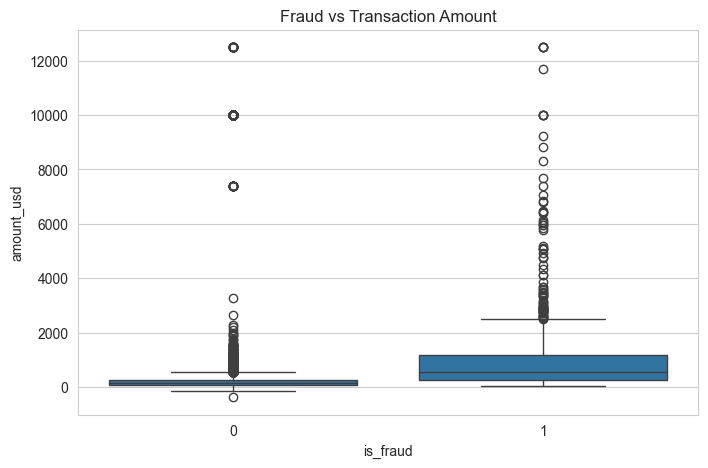

In [177]:
# Fraud vs Transaction Amount

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="amount_usd",
    data=df
)

plt.title("Fraud vs Transaction Amount")

plt.show()

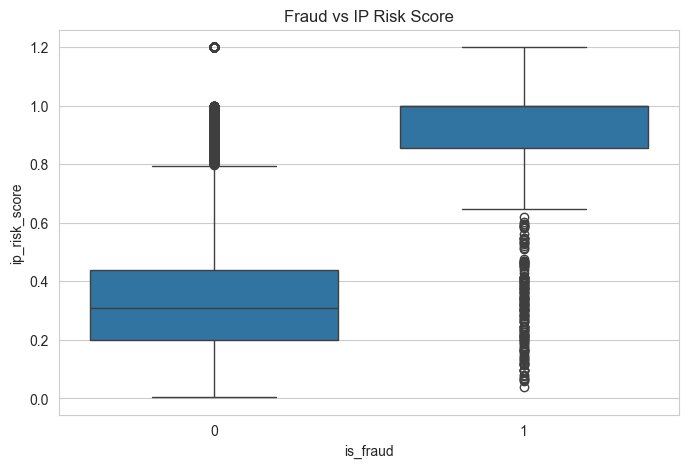

In [178]:
# Fraud vs IP Risk Score

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="ip_risk_score",
    data=df
)

plt.title("Fraud vs IP Risk Score")

plt.show()

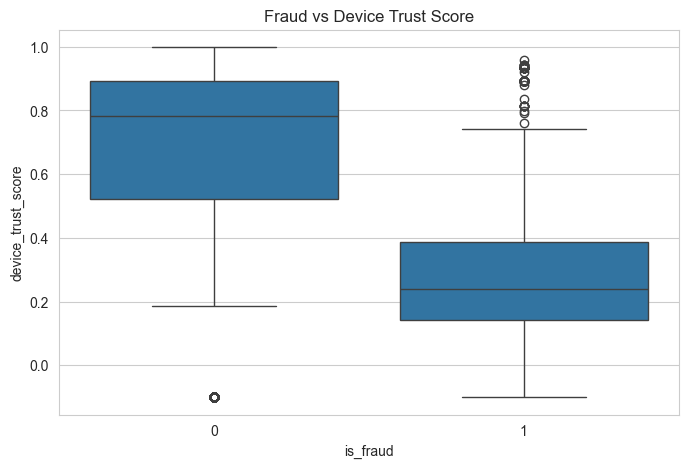

In [179]:
# Fraud vs Device Trust Score

plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="device_trust_score",
    data=df
)

plt.title("Fraud vs Device Trust Score")

plt.show()

# 3. Categorical Variable Analysis

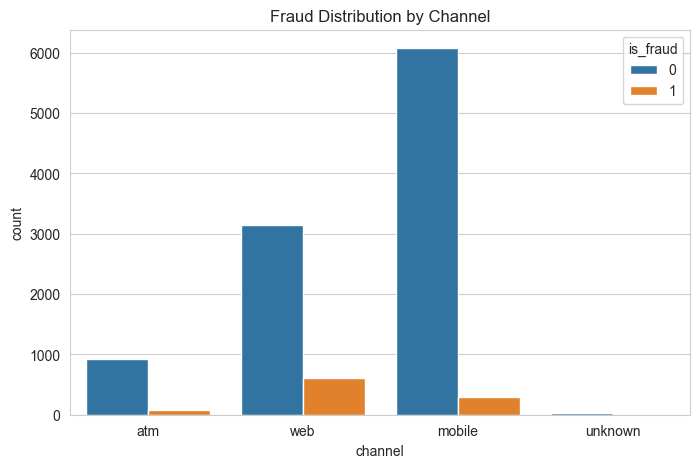

In [180]:
# Fraud by Channel

plt.figure(figsize=(8,5))

sns.countplot(
    x="channel",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by Channel")

plt.show()

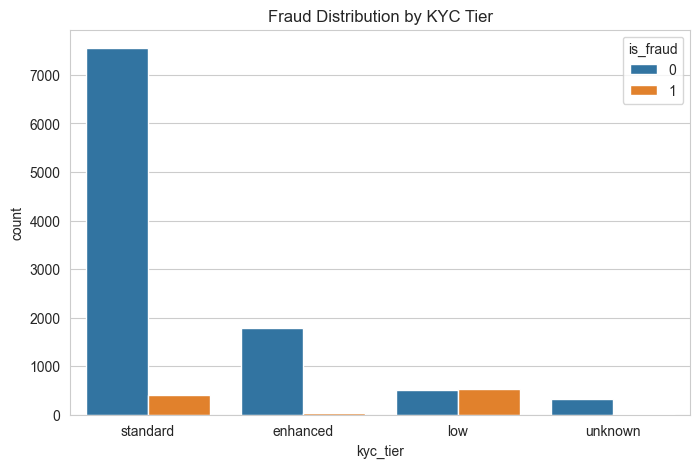

In [181]:
# Fraud by KYC Tier

plt.figure(figsize=(8,5))

sns.countplot(
    x="kyc_tier",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by KYC Tier")

plt.show()

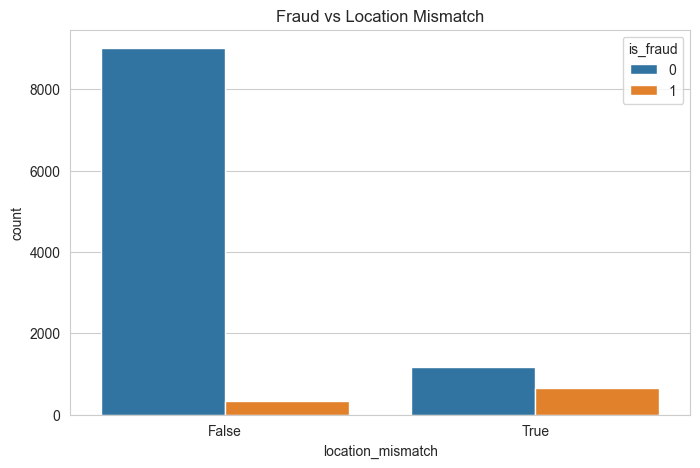

In [182]:
# Fraud by Location Mismatch

plt.figure(figsize=(8,5))

sns.countplot(
    x="location_mismatch",
    hue="is_fraud",
    data=df
)

plt.title("Fraud vs Location Mismatch")

plt.show()

# 4. Correlation Analysis

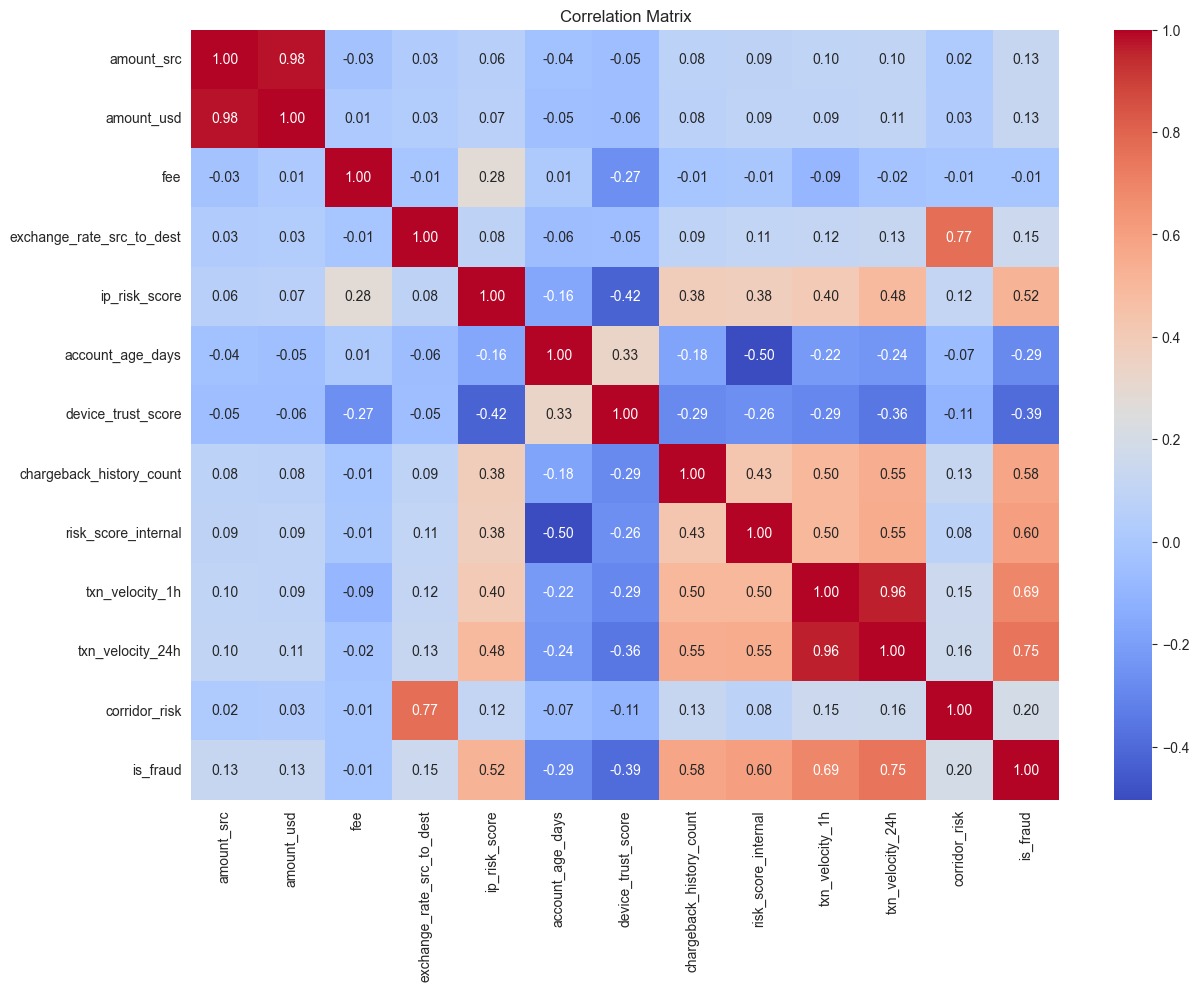

In [183]:
# Correlation Matrix

# Select numerical columns
numerical_df = df.select_dtypes(
    include=["int64", "float64"]
)

# Correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# 5. Detect Outliers 
- Using Boxplot


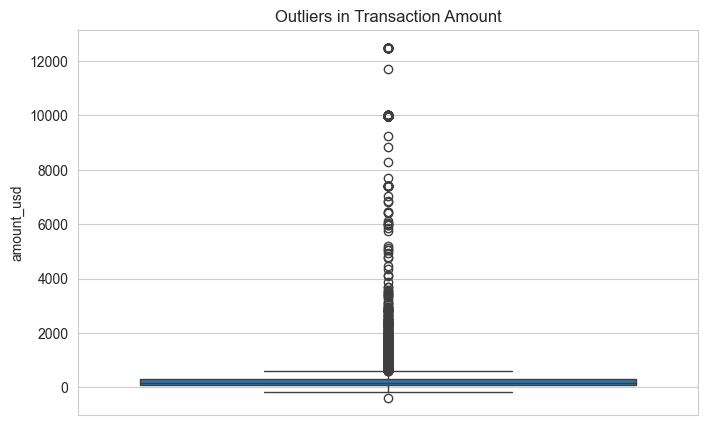

In [184]:
# Boxplot for Amount USD

plt.figure(figsize=(8,5))

sns.boxplot(y=df["amount_usd"])

plt.title("Outliers in Transaction Amount")

plt.show()

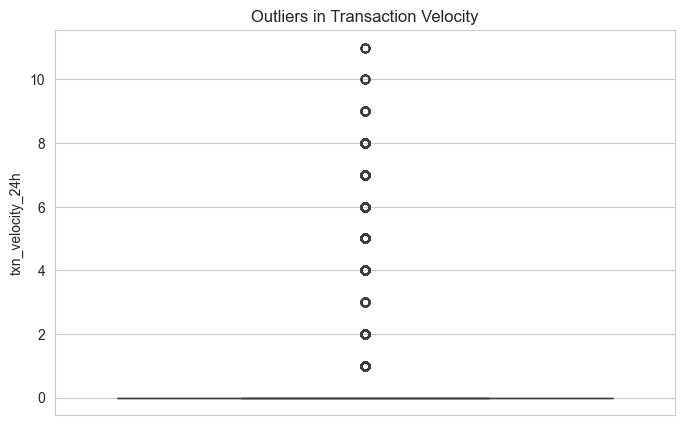

In [185]:
# Boxplot for Transaction Velocity

plt.figure(figsize=(8,5))

sns.boxplot(y=df["txn_velocity_24h"])

plt.title("Outliers in Transaction Velocity")

plt.show()

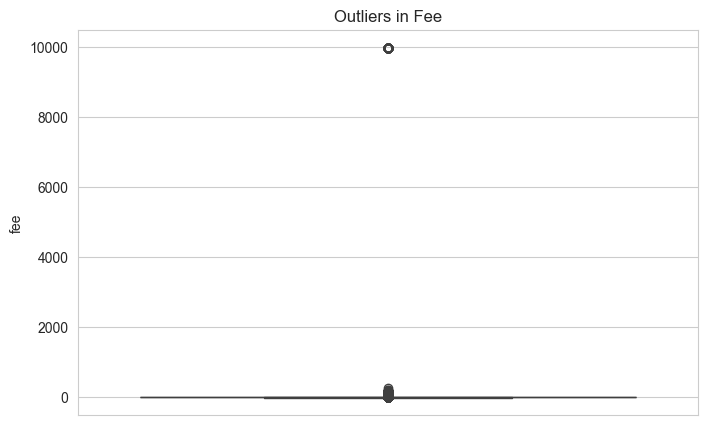

In [186]:
# Boxplot for Fee

plt.figure(figsize=(8,5))

sns.boxplot(y=df["fee"])

plt.title("Outliers in Fee")

plt.show()

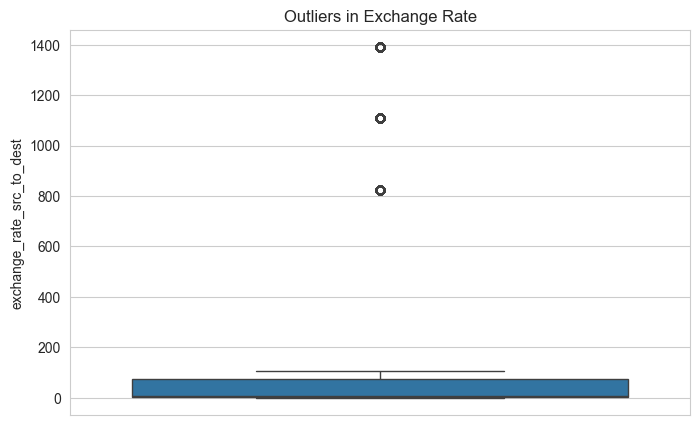

In [187]:
# Boxplot for Exchange Rate

plt.figure(figsize=(8,5))

sns.boxplot(y=df["exchange_rate_src_to_dest"])

plt.title("Outliers in Exchange Rate")

plt.show()

## Dealing with Outliers in amount_usd, Fee, and exchange rate
Note:
- This is NOT an outlier error.

- It is a valid currency conversion.

- So removing these values would damage the dataset.
### The most suitable way is by log transformation

In [188]:

# Apply log transformation to Amount USD to reduce skewness and handle outliers

df["log_amount_usd"] = np.log1p(df["amount_usd"])

# Apply log transformation to Fee to reduce skewness and handle outliers
df["log_fee"] = np.log1p(df["fee"])

# Apply log transformation to Exchange Rate to reduce skewness and handle outliers
df["log_exchange_rate"] = np.log1p(df["exchange_rate_src_to_dest"])


c:\Users\esomw\OneDrive\Documents\DataScience_Workspace\Fraud_Detection_Project\nova-venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\esomw\OneDrive\Documents\DataScience_Workspace\Fraud_Detection_Project\nova-venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Visualize After Transformation

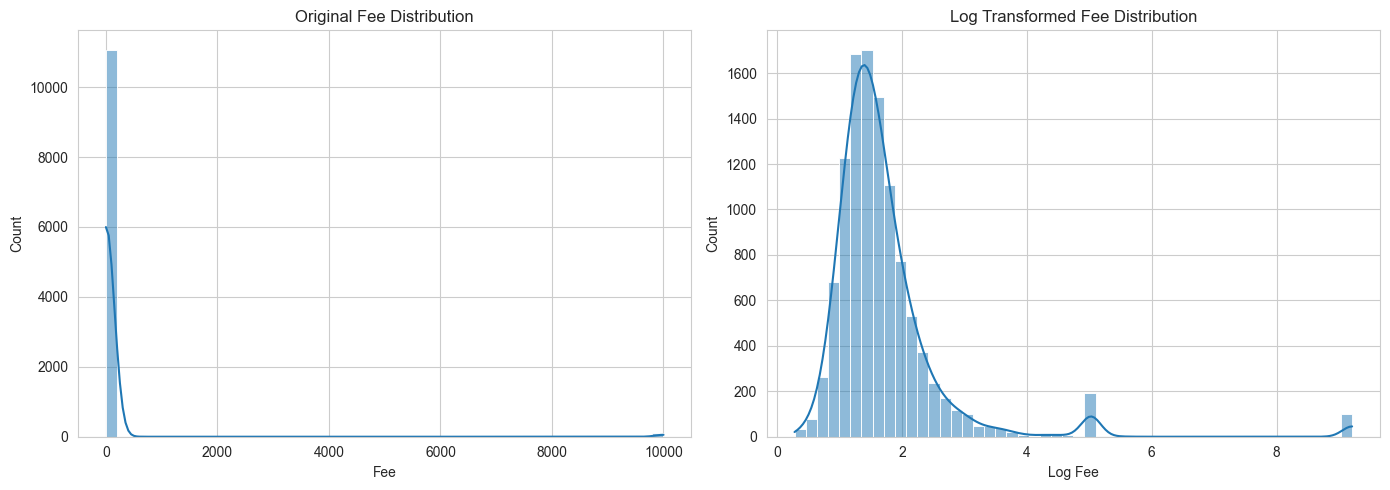

In [189]:
# =========================================
# Compare Original vs Log Fee Distribution
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Original fee distribution
sns.histplot(
    df["fee"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Fee Distribution")
axes[0].set_xlabel("Fee")


# Log transformed fee distribution
sns.histplot(
    df["log_fee"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed Fee Distribution")
axes[1].set_xlabel("Log Fee")

plt.tight_layout()

plt.show()

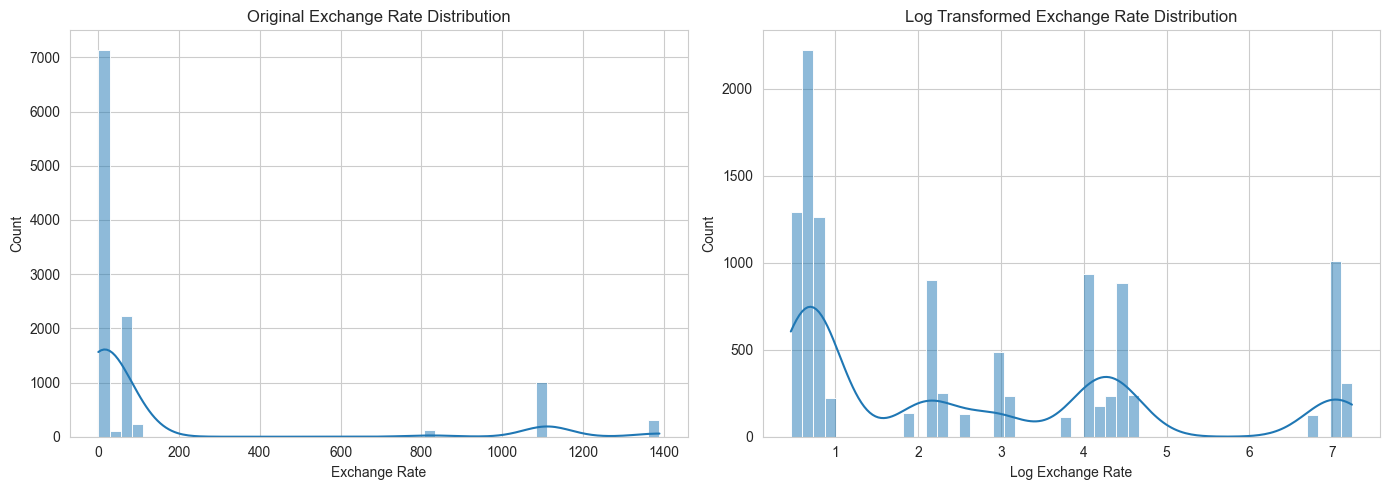

In [190]:
# =========================================
# Compare Original vs Log Exchange Rate
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Original exchange rate distribution
sns.histplot(
    df["exchange_rate_src_to_dest"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Exchange Rate Distribution")
axes[0].set_xlabel("Exchange Rate")


# Log transformed exchange rate distribution
sns.histplot(
    df["log_exchange_rate"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed Exchange Rate Distribution")
axes[1].set_xlabel("Log Exchange Rate")

plt.tight_layout()

plt.show()

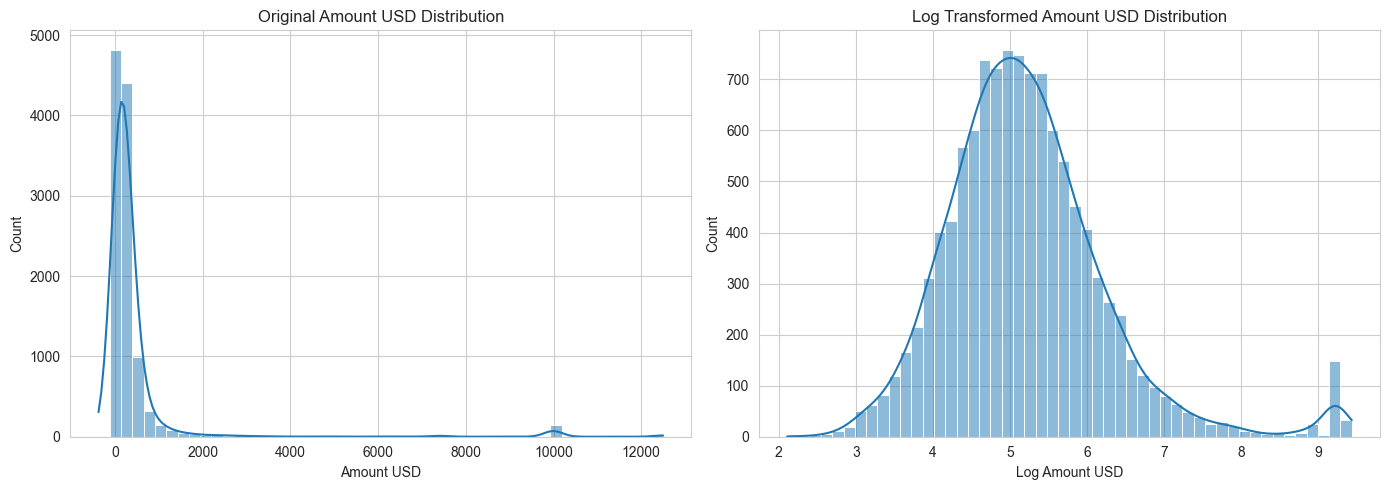

In [191]:
# =========================================
# Compare Original vs Log Amount Distribution
# =========================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Original amount distribution
sns.histplot(
    df["amount_usd"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Original Amount USD Distribution")
axes[0].set_xlabel("Amount USD")


# Log transformed amount distribution
sns.histplot(
    df["log_amount_usd"],
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Log Transformed Amount USD Distribution")
axes[1].set_xlabel("Log Amount USD")

plt.tight_layout()

plt.show()

# 6. Time-Based Fraud Analysis


In [192]:
# Restore original timestamp column
df["timestamp"] = original_df["timestamp"]

In [193]:

print(df["timestamp"].head())
print(df["timestamp"].dtype)

0    2022-10-03 18:40:59.468549+00:00
1    2022-10-03 20:39:38.468549+00:00
2    2022-10-03 23:02:43.468549+00:00
3    2022-10-04 01:08:53.468549+00:00
4    2022-10-04 09:35:03.468549+00:00
Name: timestamp, dtype: str
str


In [194]:
# Convert timestamp safely
df["timestamp"] = pd.to_datetime(
    df["timestamp"].astype(str).str.strip(),
    format="mixed",
    errors="coerce",
    utc=True
)

# Verify Conversion
print("Valid timestamps:", df["timestamp"].notnull().sum())
print("Invalid timestamps:", df["timestamp"].isnull().sum())

Valid timestamps: 11139
Invalid timestamps: 32


In [143]:
# Remove invalid timestamps
df = df.dropna(subset=["timestamp"])

In [144]:
# Create hour feature
df["transaction_hour"] = df["timestamp"].dt.hour

# Verify
print(df["transaction_hour"].unique())

[18 20 23  1  9 12 16 21 22  0  7 13 15 17 19  4  8 10 11  3 14  5  6  2]


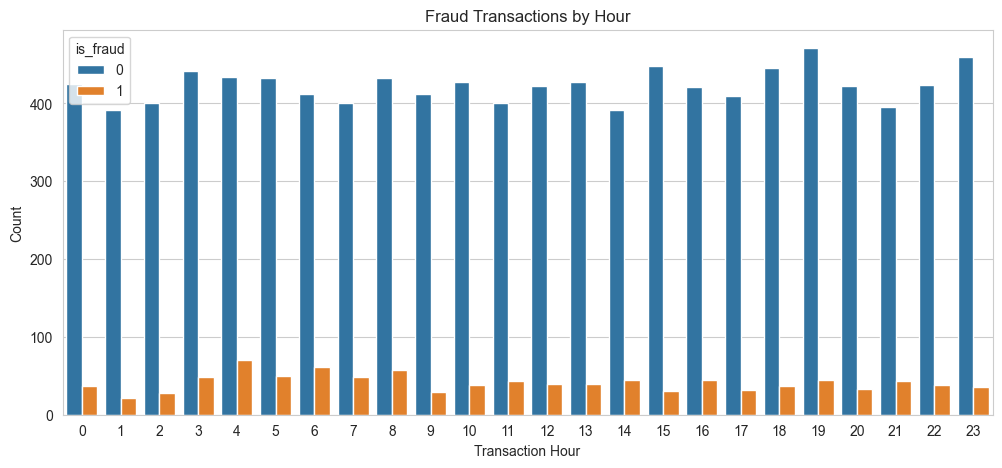

In [145]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="transaction_hour",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Count")

plt.show()

# 7. Fraud Percentage by Country

In [195]:
fraud_country = df.groupby("home_country")["is_fraud"].mean() * 100

print(fraud_country.sort_values(ascending=False))

home_country
ca         15.289256
uk         13.346044
us          6.742434
unknown     3.125000
Name: is_fraud, dtype: float64


# 8. Save EDA-Enhanced Dataset

In [ ]:
from pathlib import Path
base_dir = Path.cwd()
output_dir = base_dir / 'data' if (base_dir / 'data').exists() else base_dir.parent / 'data'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'nova_pay_eda_ready.csv'
df.to_csv(output_path, index=False)

print(f"EDA-ready dataset saved successfully to {output_path}")

OSError: Cannot save file into a non-existent directory: 'data'